# **FASE DE CARGA DE DATASET**

Autenticación en google cloud

In [ ]:
from google.colab import auth
auth.authenticate_user()
print(" Autenticado correctamente")


 Autenticado correctamente


In [ ]:
#librerias neceasarias
!pip install --quiet gcsfs pandas


In [ ]:
import numpy as np

Leer el archivo desde el bucket

In [ ]:
import pandas as pd

bucket_name = 'tfmbigdata_adrian_soler'
file_path = f'gs://{bucket_name}/order_items.csv'

# Leer el CSV desde GCS
df = pd.read_csv(file_path)

# Ver las primeras filas
df.head()


,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,43868,30107,24160,14235,118483,Cancelled,2020-10-14 13:33:08 UTC,NaN,NaN,NaN,0.02
1,13790,9483,7499,14235,37292,Complete,2023-09-13 14:57:09 UTC,2023-09-15 09:34:00 UTC,2023-09-19 12:32:00 UTC,NaN,0.02
2,39470,27121,21772,14235,106629,Complete,2021-10-08 14:53:28 UTC,2021-10-07 06:25:00 UTC,2021-10-08 16:08:00 UTC,NaN,0.02
3,12145,8374,6615,14235,32830,Processing,2025-06-26 09:00:15 UTC,NaN,NaN,NaN,0.02
4,81522,56142,44996,14235,219984,Processing,2023-12-29 23:45:28 UTC,NaN,NaN,NaN,0.02


In [ ]:
df.describe()

,id,order_id,user_id,product_id,inventory_item_id,sale_price
count,181228.00,181228.00,181228.00,181228.00,181228.00,181228.00
mean,90614.50,62425.00,50001.09,15301.45,244564.64,59.60
std,52316.16,36096.69,28921.91,8401.21,141157.89,66.49
min,1.00,1.00,1.00,1.00,3.00,0.02
25%,45307.75,31116.75,24966.75,8035.75,122348.25,24.50
50%,90614.50,62379.00,50005.00,16027.00,244415.50,39.99
75%,135921.25,93750.25,75088.50,22548.00,366746.50,69.95
max,181228.00,124962.00,100000.00,29120.00,489268.00,999.00


# **FASE DE LIMPIEZA, EXPLORACIÓN Y PREPARACIÓN**

In [ ]:
 #Ver columnas y tipos de datos
print(df.columns)
print(df.dtypes)
print(f"Filas: {df.shape[0]}  -  Columnas: {df.shape[1]}")
print(df.isnull().sum())
print(f"Duplicados: {df.duplicated().sum()}")


Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price'],
      dtype='object')
id                     int64
order_id               int64
user_id                int64
product_id             int64
inventory_item_id      int64
status                object
created_at            object
shipped_at            object
delivered_at          object
returned_at           object
sale_price           float64
dtype: object
Filas: 181228  -  Columnas: 11
id                        0
order_id                  0
user_id                   0
product_id                0
inventory_item_id         0
status                    0
created_at                0
shipped_at            63119
delivered_at         117862
returned_at          163351
sale_price                0
dtype: int64
Duplicados: 0


Vamos a quedarno solo con los pedidos completed o returned / Eliminamos columnas innecesarias

In [ ]:
# Limpieza de la columna 'status'
df['status'] = df['status'].str.strip().str.lower()

# Filtrar solo pedidos completos y devueltos
df = df[df['status'].isin(['complete', 'returned'])]

In [ ]:
# Eliminar columnas innecesarias para el análisis
df = df.drop(columns=['shipped_at', 'delivered_at', 'returned_at'])

Como el archivo no contiene la cantidad del producto vendido para hacerlo mas completo vamos a crear una columna random con la cantidad de 1 a 50, así también podremos crear la columna total_spent

In [ ]:
# Simular columna 'quantity' con valores aleatorios entre 1 y 50
np.random.seed(42)  # Para reproducibilidad
df['quantity'] = np.random.randint(1, 51, size=len(df))

# Asegurar que sale_price es tipo float
df['sale_price'] = df['sale_price'].astype(float)

# Crear columna total_spent
df['total_spent'] = df['sale_price'] * df['quantity']


In [ ]:
df.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,sale_price,quantity,total_spent
1,13790,9483,7499,14235,37292,complete,2023-09-13 14:57:09 UTC,0.02,39,0.78
2,39470,27121,21772,14235,106629,complete,2021-10-08 14:53:28 UTC,0.02,29,0.58
5,111094,76551,61355,14235,299717,returned,2023-08-23 14:17:01 UTC,0.02,15,0.30
11,121909,84018,67346,14202,328976,complete,2022-03-16 04:43:12 UTC,1.50,43,64.50
25,41618,28591,22971,14298,112390,complete,2025-02-05 16:43:03 UTC,1.72,8,13.76


In [ ]:
# Eliminar duplicados si los hubiera
df = df.drop_duplicates()

# Eliminar filas con nulos SOLO en columnas clave
df = df.dropna(subset=['user_id', 'product_id', 'sale_price', 'quantity'])

print(f" Dataset limpio y listo: {df.shape[0]} filas - {df.shape[1]} columnas")

✅ Dataset limpio y listo: 63366 filas - 10 columnas


In [ ]:

df.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,sale_price,quantity,total_spent
1,13790,9483,7499,14235,37292,complete,2023-09-13 14:57:09 UTC,0.02,39,0.78
2,39470,27121,21772,14235,106629,complete,2021-10-08 14:53:28 UTC,0.02,29,0.58
5,111094,76551,61355,14235,299717,returned,2023-08-23 14:17:01 UTC,0.02,15,0.30
11,121909,84018,67346,14202,328976,complete,2022-03-16 04:43:12 UTC,1.50,43,64.50
25,41618,28591,22971,14298,112390,complete,2025-02-05 16:43:03 UTC,1.72,8,13.76


In [ ]:
# Exportar el dataset limpio de pedidos
df.to_csv("pedidos_limpios.csv", index=False, float_format='%.2f')
print("Archivo 'pedidos_limpios.csv' exportado correctamente")


✅ Archivo 'pedidos_limpios.csv' exportado correctamente


# **FASE 2: CREACIÓN DE TABLA AGREGADA POR CLIENTE **

In [ ]:
#  1. Filtrar solo pedidos completados para calcular rentabilidad
df_completados = df[df['status'] == 'complete']

#  2. Calcular KPIs solo con pedidos completados
clientes = df_completados.groupby('user_id').agg(
    total_spent=('total_spent', 'sum'),
    n_pedidos=('order_id', 'nunique'),
    n_productos_diferentes=('product_id', 'nunique'),
    cantidad_total=('quantity', 'sum')
).reset_index()

#  3. Ticket medio
clientes['ticket_medio'] = clientes['total_spent'] / clientes['n_pedidos']

#  4. Calcular número de devoluciones por cliente
df_devueltos = df[df['status'] == 'returned']
devoluciones_por_cliente = df_devueltos.groupby('user_id').agg(
    n_pedidos_devueltos=('order_id', 'nunique')
).reset_index()

#  5. Merge y rellenar nulos con 0
clientes = clientes.merge(devoluciones_por_cliente, on='user_id', how='left')
clientes['n_pedidos_devueltos'] = clientes['n_pedidos_devueltos'].fillna(0).astype(int)

# 6. Vista previa
print(f"Clientes analizados: {clientes.shape[0]}")
clientes.head()


Clientes analizados: 27631


,user_id,total_spent,n_pedidos,n_productos_diferentes,cantidad_total,ticket_medio,n_pedidos_devueltos
0,6,2240.00,1,1,16,2240.00,0
1,7,6650.00,1,1,7,6650.00,0
2,12,5140.00,1,2,45,5140.00,0
3,13,5991.75,2,3,93,2995.87,0
4,15,3759.71,2,2,63,1879.85,0


In [ ]:
# Exportar a archivo CSV local (para subir a Power BI o al bucket)
clientes.to_csv("clientes_kpis.csv", index=False)
print(" Archivo 'clientes_kpis.csv' exportado correctamente")


✅ Archivo 'clientes_kpis.csv' exportado correctamente


**FASE 3: CREACIÓN DE TABLA AGREGADA POR PRODUCTO**

In [ ]:
#  Agrupar por product_id y calcular KPIs
productos = df.groupby('product_id').agg(
    total_facturado=('total_spent', 'sum'),
    n_ventas=('order_id', 'count'),
    cantidad_total_vendida=('quantity', 'sum'),
    n_clientes_unicos=('user_id', 'nunique')
).reset_index()

# Calcular devoluciones por producto
devoluciones_producto = df[df['status'] == 'returned'].groupby('product_id').agg(
    n_devoluciones=('order_id', 'count')
).reset_index()

#  Unir con la tabla principal de productos
productos = productos.merge(devoluciones_producto, on='product_id', how='left')

#  Rellenar con 0 en productos sin devoluciones
productos['n_devoluciones'] = productos['n_devoluciones'].fillna(0).astype(int)

# Vista previa
print(f"Productos analizados: {productos.shape[0]}")
productos.head()


Productos analizados: 25877


,product_id,total_facturado,n_ventas,cantidad_total_vendida,n_clientes_unicos,n_devoluciones
0,1,686.00,1,14,1,1
1,2,2849.50,1,41,1,1
2,3,7853.50,3,113,3,0
3,4,12096.00,3,112,3,2
4,5,3102.00,2,33,2,1


In [ ]:
productos.to_csv("productos_kpis.csv", index=False, float_format='%.2f')
print(" Archivo 'productos_kpis.csv' exportado correctamente")


✅ Archivo 'productos_kpis.csv' exportado correctamente


# **FASE 4: Clasificación de clientes**. Segmentación de los clientes usando K-Means clustering para identificar grupos según su comportamiento y rentabilidad.


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el CSV con los KPIs de clientes
clientes = pd.read_csv("/content/clientes_kpis.csv")

# Vista rápida
clientes.head()


,user_id,total_spent,n_pedidos,n_productos_diferentes,cantidad_total,ticket_medio,n_pedidos_devueltos
0,6,2240.00,1,1,16,2240.00,0
1,7,6650.00,1,1,7,6650.00,0
2,12,5140.00,1,2,45,5140.00,0
3,13,5991.75,2,3,93,2995.87,0
4,15,3759.71,2,2,63,1879.85,0


In [ ]:
# Variables que usaremos para clasificar
X = clientes[['total_spent', 'ticket_medio', 'n_pedidos', 'n_pedidos_devueltos']]

# Escalamos los datos para que todas las variables estén en la misma magnitud
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


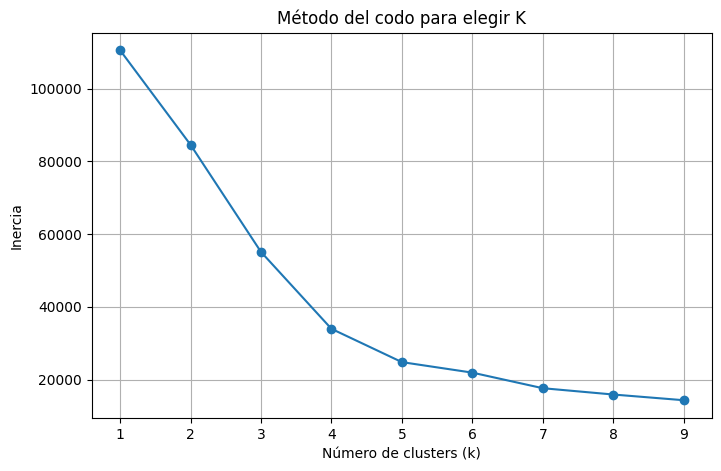

In [ ]:
# Calcular inercia para diferentes valores de k
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para elegir K')
plt.grid(True)
plt.show()

In [ ]:
# Entrenamos el modelo con k = 4
kmeans = KMeans(n_clusters=4, random_state=42)
clientes['cluster'] = kmeans.fit_predict(X_scaled)

# Vista previa con los clusters asignados
clientes.head()



,user_id,total_spent,n_pedidos,n_productos_diferentes,cantidad_total,ticket_medio,n_pedidos_devueltos,cluster
0,6,2240.00,1,1,16,2240.00,0,0
1,7,6650.00,1,1,7,6650.00,0,3
2,12,5140.00,1,2,45,5140.00,0,0
3,13,5991.75,2,3,93,2995.87,0,2
4,15,3759.71,2,2,63,1879.85,0,2


Análisis de Clusters

In [ ]:
# Agrupar por cluster y calcular la media de cada métrica
resumen_clusters = clientes.groupby('cluster').agg({
    'total_spent': 'mean',
    'ticket_medio': 'mean',
    'n_pedidos': 'mean',
    'n_pedidos_devueltos': 'mean',
    'user_id': 'count'  # Para saber cuántos clientes hay en cada grupo
}).rename(columns={'user_id': 'n_clientes'}).reset_index()

# Mostrar el resumen
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
resumen_clusters


,cluster,total_spent,ticket_medio,n_pedidos,n_pedidos_devueltos,n_clientes
0,0,1542.79,1542.79,1.00,0.00,20293
1,1,2037.01,1801.37,1.13,1.06,2432
2,2,4074.16,1920.64,2.12,0.01,2904
3,3,10122.49,9313.70,1.09,0.05,2002


In [ ]:
# Exportar la tabla segmentada de clientes
clientes.to_csv("clientes_segmentados.csv", index=False,float_format='%.2f')
print("✅ Archivo 'clientes_segmentados.csv' exportado correctamente")


✅ Archivo 'clientes_segmentados.csv' exportado correctamente


In [ ]:
# Ordenar de mayor a menor por total_spent
clientes_kpis_ordenado = clientes_kpis.sort_values(by='total_spent', ascending=False)

# Mostrar los 10 primeros
clientes_kpis_ordenado.head(10)


,user_id,total_spent,n_pedidos,n_pedidos_devueltos,ticket_medio
30387,82884,10987.16,6,0,1831.19
16791,45954,10379.87,5,0,2075.97
682,1946,10039.59,3,0,3346.53
10421,28706,9854.00,4,0,2463.50
18805,51431,9819.10,4,0,2454.78
29323,79932,9804.84,5,0,1960.97
5990,16498,9370.79,3,0,3123.60
3849,10659,9273.50,5,0,1854.70
1050,2878,9248.40,2,0,4624.20
36316,98855,9174.00,2,0,4587.00


In [ ]:
df['total'] = df['sale_price'] * df['quantity']


In [ ]:
# Agrupar por cliente
clientes_kpis = df.groupby('user_id').agg(
    total_spent=('total', 'sum'),
    n_pedidos=('order_id', 'count'),
    n_pedidos_devueltos=('status', lambda x: (x == 'Returned').sum())
).reset_index()

# Calcular ticket medio
clientes_kpis['ticket_medio'] = clientes_kpis['total_spent'] / clientes_kpis['n_pedidos']



In [ ]:
# Ordenar por total_spent
clientes_kpis_ordenado = clientes_kpis.sort_values(by='total_spent', ascending=False)

# Mostrar los 10 primeros
clientes_kpis_ordenado.head(10)


,user_id,total_spent,n_pedidos,n_pedidos_devueltos,ticket_medio
22328,61094,54947.49,6,0,9157.91
4225,11672,45668.14,4,0,11417.04
34547,94104,44550.00,1,0,44550.00
25389,69255,44247.00,1,0,44247.00
16998,46513,43496.10,2,0,21748.05
408,1210,43457.95,4,0,10864.49
7634,21121,41334.93,2,0,20667.46
33935,92489,41289.55,3,0,13763.18
16057,43943,40536.00,4,0,10134.00
29291,79840,40425.00,1,0,40425.00


In [ ]:
print(f"Precio máximo de venta: {df['sale_price'].max()}")


Precio máximo de venta: 999.0


In [ ]:
print(f"Cantidad máxima: {df['quantity'].max()}")


Cantidad máxima: 50


In [ ]:
df['total'] = df['sale_price'] * df['quantity']
print(df['total'].describe())


count   63366.00
mean     1511.44
std      2145.38
min         0.30
25%       389.74
50%       882.00
75%      1817.55
max     44550.00
Name: total, dtype: float64
